In [1]:
import pandas as pd

## load and read data

In [2]:
# Load the datasets
ms_data = pd.read_csv("ms-data.csv")
devlist = pd.read_csv("devList.csv")

In [3]:
ms_data.head()

,Unnamed: 0,pr_id,ms_id,has_conflict,top_proj,top_proj_target,top_proj_source,occ_proj,occ_proj_target,occ_proj_source,...,files_both,chunks,chunks_target,chunks_source,loc,loc_target,loc_source,commits,commits_target,commits_source
0,1,2,1,0,0,0,0,1,1,0,...,0,5,5,0,163,163,0,1,1,0
1,2,2,5,0,1,1,1,0,0,0,...,0,892,877,15,9148,6982,4562,3,3,2
2,3,2,28,0,1,1,0,0,0,0,...,0,64,64,0,1317,1929,0,6,6,0
3,4,2,32,0,1,1,0,0,0,0,...,0,7,7,0,141,141,0,2,2,0
4,5,2,34,0,1,1,0,0,0,0,...,0,31,31,0,31,31,0,1,1,0


In [4]:
ms_data['loc']

0         163
1        9148
2        1317
3         141
4          31
         ... 
78735     215
78736       9
78737      25
78738       8
78739       8
Name: loc, Length: 78740, dtype: int64

In [5]:
ms_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78740 entries, 0 to 78739
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       78740 non-null  int64
 1   pr_id            78740 non-null  int64
 2   ms_id            78740 non-null  int64
 3   has_conflict     78740 non-null  int64
 4   top_proj         78740 non-null  int64
 5   top_proj_target  78740 non-null  int64
 6   top_proj_source  78740 non-null  int64
 7   occ_proj         78740 non-null  int64
 8   occ_proj_target  78740 non-null  int64
 9   occ_proj_source  78740 non-null  int64
 10  top_ms           78740 non-null  int64
 11  top_ms_target    78740 non-null  int64
 12  top_ms_source    78740 non-null  int64
 13  occ_ms           78740 non-null  int64
 14  occ_ms_target    78740 non-null  int64
 15  occ_ms_source    78740 non-null  int64
 16  devs             78740 non-null  int64
 17  devs_target      78740 non-null  int64
 18  devs_s

In [6]:
devlist.head()

,pr_id,ms_id,cont_id,fi_l,fi_r,ch_l,ch_r,loc_l,loc_r,commits_l,...,t_commits,t_lcommits,t_rcommits,t_dev,t_l_d,t_r_d,t_both_d,code_churn,conf_loc,has_conflict
0,2,1,1,5,0,5,0,163,0,1,...,1,1,0,1,1,0,0,163,0,0
1,2,5,5,34,15,877,15,6982,4562,3,...,3,3,2,1,1,1,1,9148,0,0
2,2,28,5,47,0,64,0,1929,0,6,...,6,6,0,1,1,0,0,1317,0,0
3,2,32,5,3,0,7,0,141,0,2,...,2,2,0,1,1,0,0,141,0,0
4,2,34,5,1,0,31,0,31,0,1,...,1,1,0,1,1,0,0,31,0,0


In [7]:
len(devlist['ms_id'].unique())

78740

In [8]:
devlist['ms_id'].duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
349141    False
349142     True
349143    False
349144    False
349145    False
Name: ms_id, Length: 349146, dtype: bool

In [9]:
devlist['t_dev']

0         1
1         1
2         1
3         1
4         1
         ..
349141    2
349142    2
349143    1
349144    1
349145    1
Name: t_dev, Length: 349146, dtype: int64

In [10]:
devlist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349146 entries, 0 to 349145
Data columns (total 37 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   pr_id         349146 non-null  int64
 1   ms_id         349146 non-null  int64
 2   cont_id       349146 non-null  int64
 3   fi_l          349146 non-null  int64
 4   fi_r          349146 non-null  int64
 5   ch_l          349146 non-null  int64
 6   ch_r          349146 non-null  int64
 7   loc_l         349146 non-null  int64
 8   loc_r         349146 non-null  int64
 9   commits_l     349146 non-null  int64
 10  commits_r     349146 non-null  int64
 11  last_l        349146 non-null  int64
 12  last_r        349146 non-null  int64
 13  intg          349146 non-null  int64
 14  conflt        349146 non-null  int64
 15  core          349146 non-null  int64
 16  l_lead        349146 non-null  int64
 17  r_lead        349146 non-null  int64
 18  t_f           349146 non-null  int64
 19  t_

In [11]:
mismatches = (devlist['has_conflict'] != devlist['conflt']).sum()
mismatches

34295

### Merging both datasets

In [23]:
agg_devlist = devlist.groupby("ms_id").agg(
    num_contributors=("cont_id", "count"),
    num_core_devs=("core", "sum"),
    num_integrators=("intg", "sum"),
    num_leads_left=("l_lead", "sum"),
    num_leads_right=("r_lead", "sum"),
    total_files_changed=("fi_l", "sum"),
    total_files_right=("fi_r", "sum"),
    total_chunks_left=("ch_l", "sum"),
    total_chunks_right=("ch_r", "sum"),
    total_commits_left=("commits_l", "sum"),
    total_commits_right=("commits_r", "sum"),
    total_code_churn=("code_churn", "sum")
).reset_index()

final_dataset = ms_data.merge(agg_devlist, on="ms_id", how="left")

final_dataset.to_csv("merged_dataset.csv", index=False)

print("Aggregation and merging complete! Final dataset saved as 'merged_dataset.csv'")


Aggregation and merging complete! Final dataset saved as 'merged_dataset.csv'


In [13]:
final_dataset.head()

,Unnamed: 0,pr_id,ms_id,has_conflict,top_proj,top_proj_target,top_proj_source,occ_proj,occ_proj_target,occ_proj_source,...,num_integrators,num_leads_left,num_leads_right,total_files_changed,total_files_right,total_chunks_left,total_chunks_right,total_commits_left,total_commits_right,total_code_churn
0,1,2,1,0,0,0,0,1,1,0,...,1,1,0,5,0,5,0,1,0,163
1,2,2,5,0,1,1,1,0,0,0,...,1,1,1,34,15,877,15,3,2,9148
2,3,2,28,0,1,1,0,0,0,0,...,1,1,0,47,0,64,0,6,0,1317
3,4,2,32,0,1,1,0,0,0,0,...,1,1,0,3,0,7,0,2,0,141
4,5,2,34,0,1,1,0,0,0,0,...,1,1,0,1,0,31,0,1,0,31


## Exploratory Analysis

In [14]:
merged_conflict_analysis = final_dataset.groupby("has_conflict").mean()

In [15]:
merged_conflict_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, 0 to 1
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           2 non-null      float64
 1   pr_id                2 non-null      float64
 2   ms_id                2 non-null      float64
 3   top_proj             2 non-null      float64
 4   top_proj_target      2 non-null      float64
 5   top_proj_source      2 non-null      float64
 6   occ_proj             2 non-null      float64
 7   occ_proj_target      2 non-null      float64
 8   occ_proj_source      2 non-null      float64
 9   top_ms               2 non-null      float64
 10  top_ms_target        2 non-null      float64
 11  top_ms_source        2 non-null      float64
 12  occ_ms               2 non-null      float64
 13  occ_ms_target        2 non-null      float64
 14  occ_ms_source        2 non-null      float64
 15  devs                 2 non-null      float64
 16 

In [16]:
merged_conflict_analysis.columns = merged_conflict_analysis.columns.str.strip()
merged_conflict_analysis.drop(['Unnamed: 0','pr_id','ms_id'], axis=1, inplace=True)

In [18]:
merged_conflict_analysis

,top_proj,top_proj_target,top_proj_source,occ_proj,occ_proj_target,occ_proj_source,top_ms,top_ms_target,top_ms_source,occ_ms,...,num_integrators,num_leads_left,num_leads_right,total_files_changed,total_files_right,total_chunks_left,total_chunks_right,total_commits_left,total_commits_right,total_code_churn
has_conflict,,,,,,,,,,,,,,,,,,,,,
0,0.864928,0.611980,0.326020,3.222971,2.290814,1.019949,2.038040,1.175438,1.566052,2.049860,...,0.520872,0.884864,0.635058,16.395534,8.429496,71.524014,37.498636,9.784624,4.690948,47967.200107
1,1.748861,0.921266,1.169114,9.241519,3.204304,6.347595,1.233418,0.780506,0.610127,9.756962,...,0.948101,1.026835,1.026835,43.723291,61.756456,229.923291,299.459494,23.329873,39.719747,256653.794937


In [20]:
import pandas as pd

pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns (if needed)
pd.set_option('display.max_colwidth', None)  # Prevent text truncation
pd.set_option('display.width', 1000)  # Expand display width

In [21]:
merged_ratio = merged_conflict_analysis.iloc[1]/merged_conflict_analysis.iloc[0]
merged_ratio

top_proj                2.021972
top_proj_target         1.505385
top_proj_source         3.586024
occ_proj                2.867391
occ_proj_target         1.398762
occ_proj_source         6.223442
top_ms                  0.605198
top_ms_target           0.664013
top_ms_source           0.389595
occ_ms                  4.759820
occ_ms_target           1.949398
occ_ms_source          16.784744
devs                    2.807806
devs_target             1.497911
devs_source             5.715018
devs_both               4.291838
files                   3.964904
files_target            2.812133
files_source            6.457904
files_both             22.256073
chunks                  4.932058
chunks_target           3.327409
chunks_source           7.871439
loc                     4.776595
loc_target              3.081296
loc_source              8.500275
commits                 4.460445
commits_target          2.451871
commits_source          8.528316
num_contributors        2.688515
num_core_d

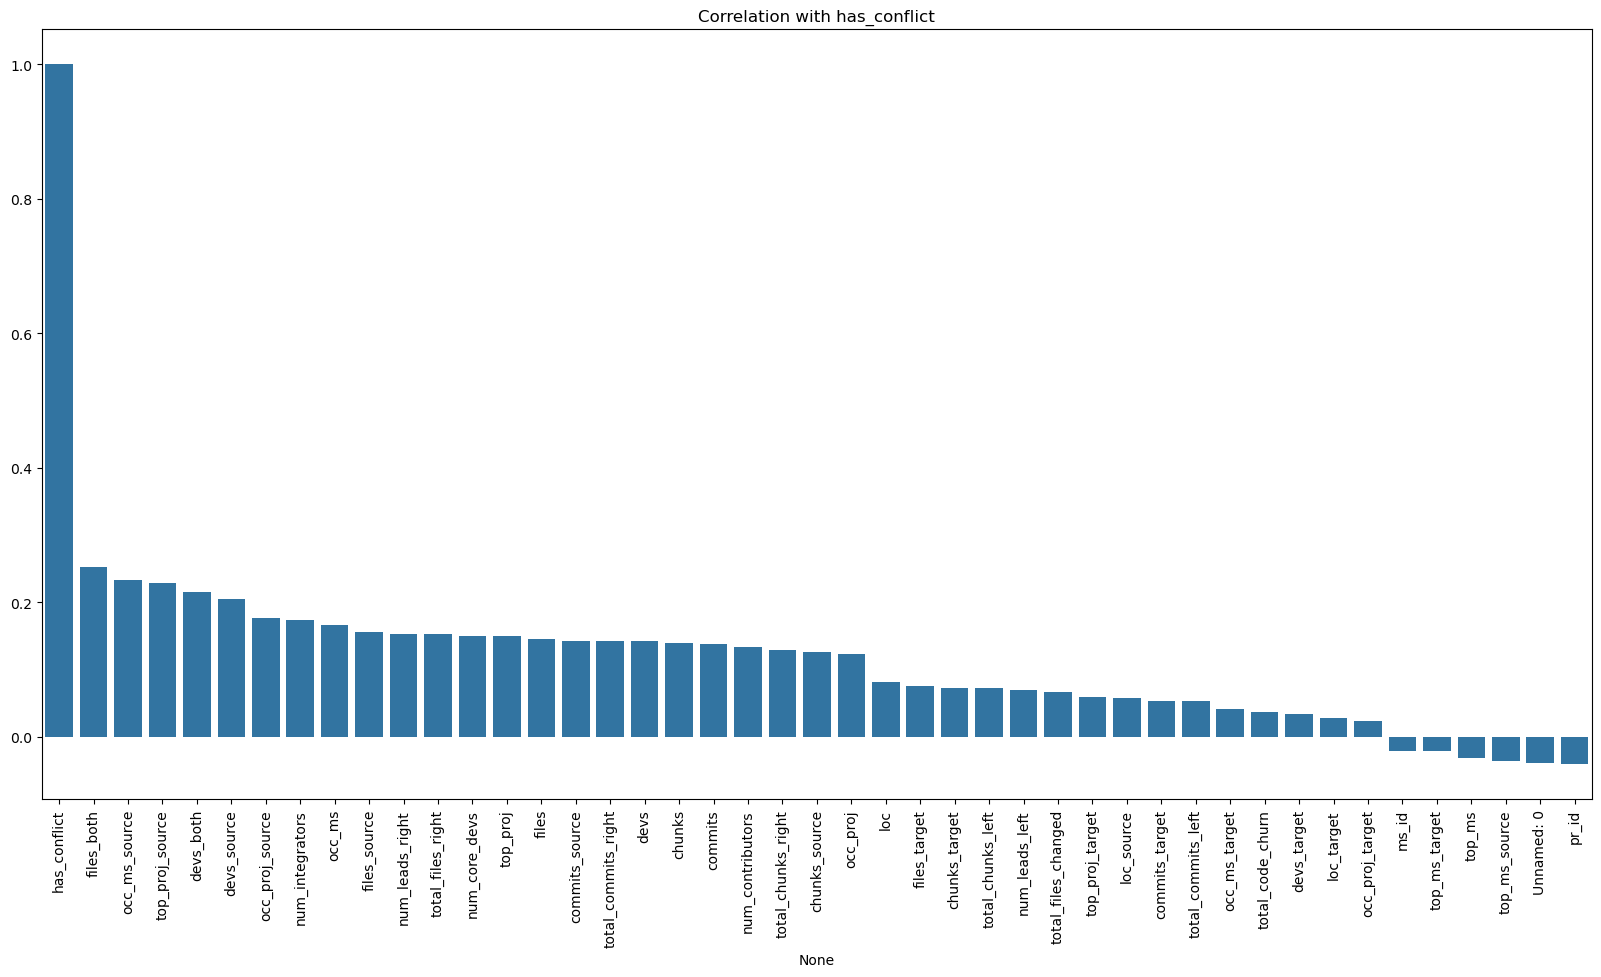

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation with `has_conflict`
correlation = final_dataset.corr()["has_conflict"].sort_values(ascending=False)

# Plot
plt.figure(figsize=(20, 10))
sns.barplot(x=correlation.index, y=correlation.values)
plt.xticks(rotation=90)
plt.title("Correlation with has_conflict")
plt.show()


# Merged Dataset Documentation

## Overview

This dataset is designed for predicting the likelihood of merge conflicts in software repositories. It combines social and technical factors by merging data from `ms-data.csv` (merge scenario-level data) and aggregated `devList.csv` (developer-level data). The dataset contains one row per merge scenario (`ms_id`), providing a comprehensive view of the factors influencing merge conflicts.

## Source Datasets

1. **ms-data.csv**: Contains high-level merge scenario information, such as the number of files changed, lines of code modified, and involvement of top or occasional contributors.
2. **devList.csv**: Provides developer-specific details, aggregated per merge scenario, including the number of core developers, integrators, commits, and code churn.

## Comparison with Other Datasets

| Feature                    | MSR14 Dataset                | MESTRE Dataset                                          | 4CsNet Dataset                                                            |
| -------------------------- | ---------------------------- | ------------------------------------------------------- | ------------------------------------------------------------------------- |
| **Granularity**            | Repository-level             | Conflict-level                                          | Merge scenario-level                                                      |
| **Social Factors**         | No                           | Limited                                                 | Extensive (developer roles, contributions)                                |
| **Technical Factors**      | Yes                          | Yes                                                     | Yes (more detailed, combines sources)                                     |
| **Conflict Label**         | No (requires processing)     | Yes (only conflicting merges, no non-conflicting cases) | Yes (has\_conflict column, includes both conflict and non-conflict cases) |
| **Number of Repositories** | 100+                         | Limited                                                 | 66 projects                                                               |
| **Merge Scenario Details** | Basic PR-level               | Fine-grained conflict chunks                            | Full PR and developer-level summary                                       |
| **Usability for DL**       | Requires heavy preprocessing | Focused on fine-grained conflicts                       | Ready for predictive modeling                                             |

## Usage

This dataset is intended for deep learning models to predict `has_conflict` (whether a merge scenario will result in a conflict). The features include:

- **Social Factors:** Developer roles, contributor experience, and leadership in the merge scenario.
- **Technical Factors:** Code complexity, number of modified files, commits, and code churn.

## Features

| Column Name               | Description                                                                                             |
| ------------------------- | ------------------------------------------------------------------------------------------------------- |
| **ms\_id**                | Unique identifier for the merge scenario.                                                               |
| **has\_conflict**         | Binary indicator (1 = conflict, 0 = no conflict) for whether the merge scenario resulted in a conflict. |
| **top\_proj**             | Number of top contributors involved in the project.                                                     |
| **top\_proj\_target**     | Number of top contributors involved in the target branch.                                               |
| **top\_proj\_source**     | Number of top contributors involved in the source branch.                                               |
| **occ\_proj**             | Number of occasional contributors involved in the project.                                              |
| **occ\_proj\_target**     | Number of occasional contributors involved in the target branch.                                        |
| **occ\_proj\_source**     | Number of occasional contributors involved in the source branch.                                        |
| **top\_ms**               | Number of top contributors involved in the merge scenario.                                              |
| **top\_ms\_target**       | Number of top contributors involved in the target branch during the merge scenario.                     |
| **top\_ms\_source**       | Number of top contributors involved in the source branch during the merge scenario.                     |
| **occ\_ms**               | Number of occasional contributors involved in the merge scenario.                                       |
| **occ\_ms\_target**       | Number of occasional contributors involved in the target branch.                                        |
| **occ\_ms\_source**       | Number of occasional contributors involved in the source branch.                                        |
| **devs**                  | Number of developers involved in the merge scenario.                                                    |
| **devs\_target**          | Number of developers contributing to the target branch.                                                 |
| **devs\_source**          | Number of developers contributing to the source branch.                                                 |
| **devs\_both**            | Number of developers contributing to both branches.                                                     |
| **files**                 | Total number of files affected in the merge scenario.                                                   |
| **files\_target**         | Number of files changed in the target branch.                                                           |
| **files\_source**         | Number of files changed in the source branch.                                                           |
| **files\_both**           | Number of files modified in both branches.                                                              |
| **chunks**                | Total number of code chunks changed in the merge scenario.                                              |
| **chunks\_target**        | Number of code chunks changed in the target branch.                                                     |
| **chunks\_source**        | Number of code chunks changed in the source branch.                                                     |
| **loc**                   | Total lines of code changed in the merge scenario.                                                      |
| **loc\_target**           | Lines of code changed in the target branch.                                                             |
| **loc\_source**           | Lines of code changed in the source branch.                                                             |
| **commits**               | Total number of commits involved in the merge scenario.                                                 |
| **commits\_target**       | Number of commits in the target branch.                                                                 |
| **commits\_source**       | Number of commits in the source branch.                                                                 |
| **num\_contributors**     | Total number of developers involved in the merge scenario.                                              |
| **num\_core\_devs**       | Number of core developers (highly active developers) involved.                                          |
| **num\_integrators**      | Number of integrators (developers responsible for merging code).                                        |
| **num\_leads\_left**      | Number of developers leading changes in the left branch.                                                |
| **num\_leads\_right**     | Number of developers leading changes in the right branch.                                               |
| **total\_files\_changed** | Total number of files changed in the merge scenario (sum of left and right).                            |
| **total\_files\_right**   | Number of files changed in the right branch.                                                            |
| **total\_chunks\_left**   | Number of code chunks modified in the left branch.                                                      |
| **total\_chunks\_right**  | Number of code chunks modified in the right branch.                                                     |
| **total\_commits\_left**  | Number of commits made in the left branch.                                                              |
| **total\_commits\_right** | Number of commits made in the right branch.                                                             |
| **total\_code\_churn**    | Total amount of code added, modified, or deleted in the merge scenario.                                 |

## Preprocessing Steps

1. **Remove Data Leakage Features:** If features directly indicate conflicts (e.g., `conflict_loc`), they should be removed.
2. **Feature Engineering :** Create new metrics such as file overlap ratios or commit ratios.

## Applications

- Training Deep learning models to predict merge conflicts.
- Understanding social and technical factors that contribute to conflicts.
- Improving software development workflows by predicting and mitigating conflicts in advance.

## References

- Gustavo Vale's Repository: [Predicting Merge Conflicts Considering Social and Technical Assets](https://github.com/GustavoVale/predicting-merge-conflicts-considering-social-and-technical-assets/tree/main)

This dataset is structured to facilitate deep learning and active learning techniques for **merge conflict prediction**. 🚀

